In [1]:
from datascience import *
%matplotlib inline
path_data = 'data/'
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


# 최소 제곱 회귀 (Least Squares Regression)
이전 섹션에서 우리는 *럭비공 모양*의 산점도를 통과하는 회귀선의 기울기와 절편에 대한 공식을 개발했습니다. 최소 제곱선의 기울기와 절편은 *산점도의 모양과 관계없이* 우리가 개발한 것과 동일한 공식을 갖는 것으로 밝혀졌습니다.

우리는 작은 아씨들(Little Women)에 대한 예제에서 이것을 보았지만, 산점도가 명백히 럭비공 모양이 아닌 예제에서 이를 확인해 봅시다. 데이터에 대해서는 플로리다 대학교의 [래리 위너(Larry Winner) 교수의 풍부한 데이터 아카이브](http://www.stat.ufl.edu/~winner/datasets.html)에 다시 한 번 신세를 졌습니다. 국제 운동 과학 저널(International Journal of Exercise Science)의 [2013년 연구](http://digitalcommons.wku.edu/ijes/vol6/iss2/10/)는 대학 투포환 선수들을 연구하고 근력과 투포환 거리 사이의 관계를 조사했습니다. 모집단은 28명의 여자 대학 선수로 구성됩니다. 근력은 프리시즌에 선수가 "1RM 파워 클린"에서 들어 올린 최대량(kg)으로 측정되었습니다. 거리(m)는 선수의 개인 최고 기록이었습니다.

In [3]:
def standard_units(any_numbers):
    "Convert any array of numbers to standard units."
    return (any_numbers - np.mean(any_numbers))/np.std(any_numbers)

def correlation(t, x, y):
    return np.mean(standard_units(t.column(x))*standard_units(t.column(y)))

def slope(table, x, y):
    r = correlation(table, x, y)
    return r * np.std(table.column(y))/np.std(table.column(x))

def intercept(table, x, y):
    a = slope(table, x, y)
    return np.mean(table.column(y)) - a * np.mean(table.column(x))

def fit(table, x, y):
    """Return the height of the regression line at each x value."""
    a = slope(table, x, y)
    b = intercept(table, x, y)
    return a * table.column(x) + b

In [4]:
shotput = Table.read_table(path_data + 'shotput.csv')

In [5]:
shotput

Weight Lifted,Shot Put Distance
37.5,6.4
51.5,10.2
61.3,12.4
61.3,13
63.6,13.2
66.1,13
70,12.7
92.7,13.9
90.5,15.5
90.5,15.8


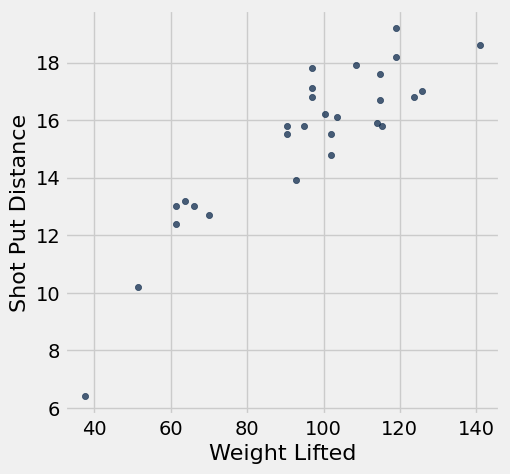

In [6]:
shotput.scatter('Weight Lifted')

그것은 럭비공 모양의 산점도가 아닙니다. 사실 약간의 비선형 성분이 있는 것 같습니다. 하지만 우리가 예측을 위해 직선을 사용하겠다고 고집한다면, 여전히 모든 직선 중에서 하나의 최적의 직선이 있습니다.

럭비공 모양의 산점도에 대해 유도된 회귀선의 기울기와 절편에 대한 우리의 공식은 다음 값을 제공합니다.

In [7]:
slope(shotput, 'Weight Lifted', 'Shot Put Distance')

0.098343821597819972

In [8]:
intercept(shotput, 'Weight Lifted', 'Shot Put Distance')

5.9596290983739522

산점도가 럭비공 모양이 아닌데도 이 공식을 사용하는 것이 여전히 말이 될까요? mse를 최소화하는 선의 기울기와 절편을 찾아 이에 답할 수 있습니다.

임의의 기울기와 절편을 인수로 받아 해당 mse를 반환하는 `shotput_linear_mse` 함수를 정의하겠습니다. 그런 다음 `shotput_linear_mse`에 적용된 `minimize`는 최적의 기울기와 절편을 반환할 것입니다.

In [9]:
def shotput_linear_mse(any_slope, any_intercept):
    x = shotput.column('Weight Lifted')
    y = shotput.column('Shot Put Distance')
    fitted = any_slope*x + any_intercept
    return np.mean((y - fitted) ** 2)

In [10]:
minimize(shotput_linear_mse)

array([ 0.09834382,  5.95962911])

이 값들은 공식을 사용하여 얻은 값과 동일합니다. 요약하자면:

**산점도의 모양이 무엇이든 추정의 평균 제곱 오차를 최소화하는 유일한 선이 있습니다. 이를 회귀선이라고 하며, 기울기와 절편은 다음과 같이 주어집니다.**

$$
\mathbf{\text{slope of the regression line}} ~=~ r \cdot
\frac{\text{SD of }y}{\text{SD of }x}
$$

$$
\mathbf{\text{intercept of the regression line}} ~=~
\text{average of }y ~-~ \text{slope} \cdot \text{average of }x
$$

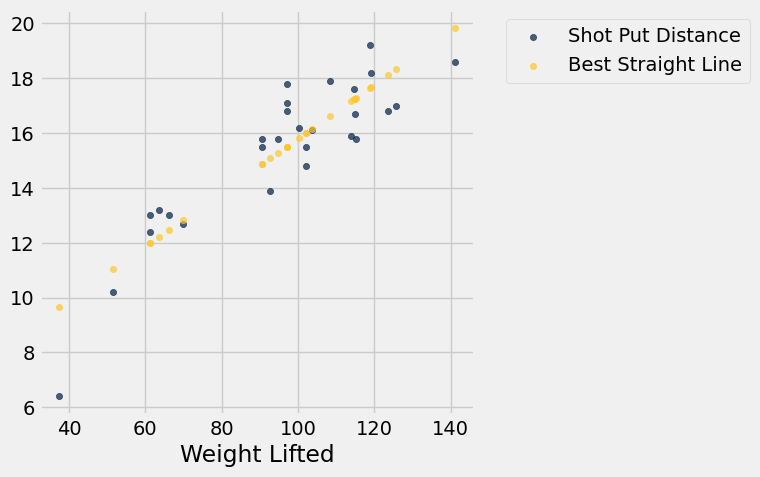

In [11]:
fitted = fit(shotput, 'Weight Lifted', 'Shot Put Distance')
shotput.with_column('Best Straight Line', fitted).scatter('Weight Lifted')

## 비선형 회귀 (Nonlinear Regression)
위의 그래프는 산점도가 약간 구부러져 있다는 우리의 초기 관찰을 강화합니다. 따라서 직선보다 곡선을 맞추는 것이 더 좋습니다. [연구](http://digitalcommons.wku.edu/ijes/vol6/iss2/10/)는 들어 올린 무게와 투포환 거리 사이의 2차 관계를 가정했습니다. 따라서 2차 함수를 예측 변수로 사용하고 가장 좋은 것을 찾을 수 있는지 봅시다.

우리는 모든 직선 중에서 최적의 직선을 찾는 대신 모든 2차 함수 중에서 최적의 2차 함수를 찾아야 합니다. 최소 제곱법을 사용하면 이를 수행할 수 있습니다.

이 최소화의 수학은 복잡하며 산점도를 검사하는 것만으로는 쉽게 알 수 없습니다. 하지만 수치 최소화는 선형 예측 변수와 마찬가지로 쉽습니다! 다시 한 번 `minimize`를 사용하여 최적의 2차 예측 변수를 얻을 수 있습니다. 어떻게 작동하는지 봅시다.

2차 함수는 상수 $a$, $b$, $c$에 대해 다음과 같은 형태를 가짐을 상기하십시오.

$$
f(x) ~=~ ax^2 + bx + c
$$

최소 제곱 기준을 사용하여 들어 올린 무게를 기반으로 거리를 예측하는 최적의 2차 함수를 찾으려면, 먼저 세 상수를 인수로 받아 위의 2차 함수를 사용하여 적합값을 계산한 다음 평균 제곱 오차를 반환하는 함수를 작성해야 합니다.

이 함수는 `shotput_quadratic_mse`라고 합니다. 정의가 `lw_mse`와 유사하지만 적합값이 선형 대신 2차 함수를 기반으로 한다는 점에 주목하십시오.

In [12]:
def shotput_quadratic_mse(a, b, c):
    x = shotput.column('Weight Lifted')
    y = shotput.column('Shot Put Distance')
    fitted = a*(x**2) + b*x + c
    return np.mean((y - fitted) ** 2)

이제 이전과 마찬가지로 `minimize`를 사용하여 평균 제곱 오차를 최소화하는 상수를 찾을 수 있습니다.

In [13]:
best = minimize(shotput_quadratic_mse)
best

array([ -1.04004838e-03,   2.82708045e-01,  -1.53182115e+00])

$x$ 킬로그램을 들어 올리는 선수의 투포환 거리에 대한 우리의 예측은 약

$$
-0.00104x^2 ~+~ 0.2827x - 1.5318
$$

미터입니다. 예를 들어, 선수가 100킬로그램을 들어 올릴 수 있다면 예측 거리는 16.33미터입니다. 산점도에서 이는 100킬로그램 주변 수직 띠의 중심 근처입니다.

In [14]:
(-0.00104)*(100**2) + 0.2827*100 - 1.5318

16.3382

다음은 모든 `Weight Lifted` 값에 대한 예측입니다. 대략적인 근사치로 산점도의 중심을 통과하는 것을 볼 수 있습니다.

In [15]:
x = shotput.column(0)
shotput_fit = best.item(0)*(x**2) + best.item(1)*x + best.item(2)

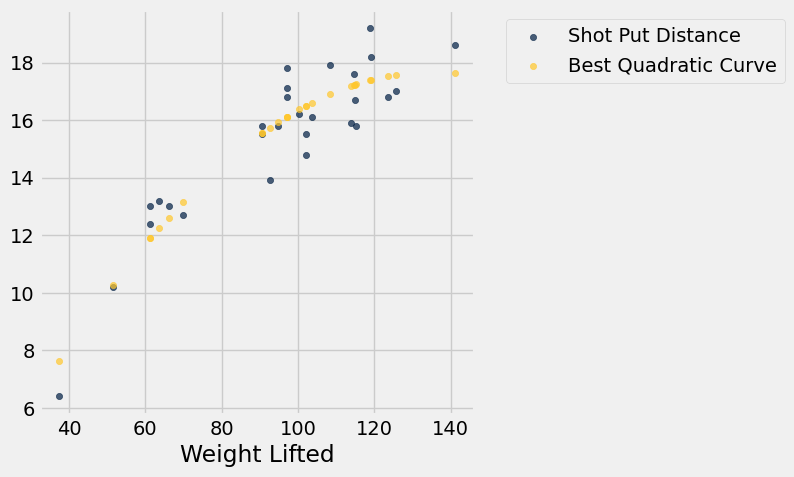

In [16]:
shotput.with_column('Best Quadratic Curve', shotput_fit).scatter(0)

**참고:** 원래 연구에서 제안되었기 때문에 여기서는 2차 함수를 맞추었습니다. 그러나 그래프의 맨 오른쪽 끝에서 2차 곡선이 정점에 가까워지는 것처럼 보이며, 그 후에는 곡선이 아래로 내려가기 시작할 것이라는 점에 주목할 가치가 있습니다. 따라서 우리 데이터 세트에 있는 것보다 훨씬 더 높은 무게를 들어 올릴 수 있는 새로운 선수에게는 이 모델을 사용하고 싶지 않을 수 있습니다.